In [55]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from IPython.display import Image

In [56]:
model = ChatOllama(model="mistral")
class GetInfo(BaseModel):
    issue_type: Annotated[str, Field(description="Find the type of issue from the given feedback. Summarize the issue in one line.")]

    tone: Annotated[Literal["positive", "negative", "neutral"], Field(description="Determine the tone of the feedback. It can be positive, negative or neutral.")]

    urgency: Annotated[Literal["low", "medium", "high"], Field(description="Determine the urgency of the feedback. It can be low, medium or high.")]

negative_info = model.with_structured_output(GetInfo)

In [57]:
sentiment_model = ChatOllama(model="mistral")
class GetSentiment(BaseModel):
    senti: Annotated[Literal["positive", "negative", "neutral"], Field(description="Determine the sentiment of the feedback. It can be positive, negative or neutral.")]
sentiment_info = sentiment_model.with_structured_output(GetSentiment)
class FeedbackState(TypedDict):
    feedback: str
    sentiment: Literal["positive", "negative", "neutral"]
    diagnosis: dict
    response: str

In [58]:
def get_sentiment(state: FeedbackState) -> FeedbackState:
    prompt = ChatPromptTemplate.from_template("Determine the sentiment of the following feedback: {feedback}")
    chain = prompt | sentiment_info
    output = chain.invoke({"feedback": state["feedback"]}).senti
    return {"sentiment": output}

# FIX 1: Accessing dict keys natively rather than using object properties
def sentiment_type(state: FeedbackState) -> Literal["positive_message", "get_sentiment_info"]:
    if state.get("sentiment") == "negative":
        return "get_sentiment_info"
    else:
        return "positive_message"

def positive_message(state: FeedbackState) -> FeedbackState:
    return {"response": "Thank you for your feedback! We're glad you had a positive experience."}

def get_sentiment_info(state: FeedbackState) -> FeedbackState:
    prompt = ChatPromptTemplate.from_template("The feedback is negative. Find the type of issue from the given feedback. Summarize the issue in one line. Also determine the urgency of the issue. It can be low, medium or high. Determine the tone of the feedback. It can be positive, negative or neutral.\nFeedback: {feedback}")
    chain = prompt | negative_info
    info = chain.invoke({"feedback": state["feedback"]})
    return {"diagnosis": info.model_dump()}

# FIX 2: Fixed state.feedback syntax error down here
def response(state: FeedbackState) -> FeedbackState:
    prompt = ChatPromptTemplate.from_template("Generate a response for the following feedback based on the diagnosis of the issue.\nFeedback: {feedback}\nDiagnosis: {diagnosis}")
    llm = ChatOllama(model="mistral")
    chain = prompt | llm | StrOutputParser()
    response = chain.invoke({"feedback": state["feedback"], "diagnosis": state.get("diagnosis", {})})
    return {"response": response}

In [59]:
graph = StateGraph(FeedbackState)

graph.add_node("get_sentiment", get_sentiment)
# graph.add_node("sentiment_type", sentiment_type)
graph.add_node("positive_message", positive_message)
graph.add_node("get_sentiment_info", get_sentiment_info)
graph.add_node("response", response)

graph.add_edge(START, "get_sentiment")
graph.add_conditional_edges("get_sentiment", sentiment_type)
graph.add_edge("positive_message", END)
graph.add_edge("get_sentiment_info", "response")
graph.add_edge("response", END)

workflow = graph.compile()

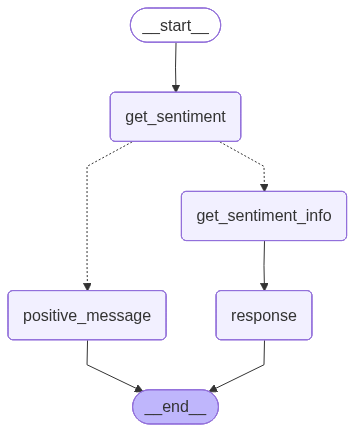

In [60]:
Image(workflow.get_graph().draw_mermaid_png())

In [61]:
query = {
    "feedback": "The product stopped working after a week. I'm very disappointed with the quality."
}
out = workflow.invoke(query)

In [62]:
out

{'feedback': "The product stopped working after a week. I'm very disappointed with the quality.",
 'sentiment': 'negative',
 'diagnosis': {'issue_type': 'Hardware malfunction',
  'tone': 'negative',
  'urgency': 'high'},
 'response': " Dear Customer,\n\nI'm truly sorry to hear about the inconvenience you're experiencing with our product. A week is too short for a product to malfunction and I understand your disappointment with the quality. Our top priority is customer satisfaction and it seems we've fallen short in this instance.\n\nTo rectify the situation, I would like to offer a replacement product at no additional cost. For this, I will need the product model number and the order ID if possible, so our support team can process your request efficiently.\n\nIn the meantime, please let us know if you have any other concerns or questions. We're committed to resolving this issue promptly and ensuring that your experience with us moving forward is a positive one.\n\nThank you for bringin